### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs

#### Parte 5 - Classificação supervisionada com SVM e Random Forest

- `SVM` com padronização (`StandardScaler`)
- `RandomForestClassifier`
- `Tuning Leve`

## Sumário da Parte 5

### Item 1 - Carregamento da base e definição do target
### Item 2 - Seleção de features e prevenção de vazamento
### Item 3 - Separação treino/teste
### Item 4 - Pré-processamento com `ColumnTransformer`
### Item 5 - Tuning leve do SVM
### Item 6 - Tuning leve do Random Forest
### Item 7 - Avaliação final no conjunto de teste
### Item 8 - Comparação dos modelos

#### Item 1 - Carregamento da base e definição do target

Nesta etapa carregamos a base tratada e criamos a variável binária `TARGET`:
- `0` para casos sem indício
- `1` para casos com indício (`CANCER_MAMA_NIVEL > 0`)

Também verificamos dimensões da base e distribuição das classes.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

candidate_paths = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
    Path('/content/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/ia_tech_challenge_01/2025_tratado.parquet'),
]

path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if path is None:
    searched = '\n'.join(f'- {candidate}' for candidate in candidate_paths)
    raise FileNotFoundError(
        'Arquivo de base tratada não encontrado. Verifique onde o arquivo '
        "'2025_tratado.parquet' foi salvo e ajuste o caminho na célula.\n"
        f'Caminhos verificados:\n{searched}'
    )

print(f'Arquivo localizado em: {path.resolve()}')
dados = pd.read_parquet(path)

TARGET = 'TARGET'
dados[TARGET] = (dados['CANCER_MAMA_NIVEL'] > 0).astype(int)

print('Dimensões da base tratada:', dados.shape)
print('\nDistribuição do target:')
print(dados[TARGET].value_counts().sort_index())
print('\nProporção do target:')
print(dados[TARGET].value_counts(normalize=True).sort_index().rename('proporcao'))

Arquivo localizado em: C:\Users\Rodrigo\Desktop\Pós\Tech_Challenge_1\ia_tech_challenge_01\2025_tratado.parquet
Dimensões da base tratada: (857726, 76)

Distribuição do target:
TARGET
0    848560
1      9166
Name: count, dtype: int64

Proporção do target:
TARGET
0    0.989314
1    0.010686
Name: proporcao, dtype: float64


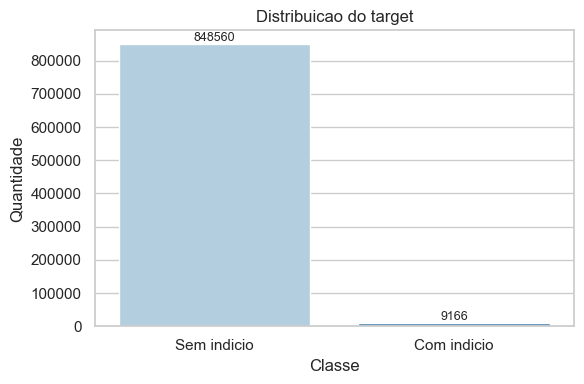

In [4]:
plot_df = dados[TARGET].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
plot_df['Classe'] = plot_df['Classe'].map({0: 'Sem indicio', 1: 'Com indicio'})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_df, x='Classe', y='Quantidade', hue='Classe', palette='Blues', legend=False)
ax.set_title('Distribuicao do target')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
    )
plt.tight_layout()
plt.show()

#### Item 2 - Seleção de features e prevenção de vazamento

A seleção de atributos prioriza variáveis administrativas e demográficas, evitando colunas diretamente associadas ao diagnóstico detalhado para reduzir risco de vazamento.

In [5]:
feature_candidates = [
    'IDADE_ANOS',
    'DIAS_PERM',
    'QT_DIARIAS',
    'UTI_MES_IN',
    'UTI_MES_AN',
    'UTI_MES_AL',
    'UTI_MES_TO',
    'UTI_INT_IN',
    'UTI_INT_AN',
    'UTI_INT_AL',
    'UTI_INT_TO',
    'DIAR_ACOM',
    'SEXO',
    'RACA_COR',
    'GESTRISCO',
    'CONTRACEP1',
    'CONTRACEP2',
    'PROC_REA',
]

leakage_columns = [
    'CANCER_MAMA_NIVEL',
    'DIAG_PRINC',
    'DIAGSEC1',
    'DIAGSEC2',
    'DIAGSEC3',
    'DIAGSEC4',
    'DIAGSEC5',
    'DIAGSEC6',
    'DIAGSEC7',
    'CID_MORTE',
    'DIAG_PRINC_GRUPO',
]

features = [col for col in feature_candidates if col in dados.columns]
leakage_present = [col for col in leakage_columns if col in dados.columns]

numerical_features = [col for col in features if dados[col].dtype.kind in 'biufc']
categorical_features = [col for col in features if col not in numerical_features]

low_cardinality_features = []
high_cardinality_features = []
for col in categorical_features:
    nunique = dados[col].nunique(dropna=False)
    if nunique <= 20:
        low_cardinality_features.append(col)
    else:
        high_cardinality_features.append(col)

selected_features = numerical_features + low_cardinality_features
X = dados[selected_features].copy()
y = dados[TARGET].copy()

print('Features selecionadas para modelagem:')
print(selected_features)
print('\nColunas sensíveis identificadas e excluídas:')
print(leakage_present)
print('\nCategóricas excluídas por alta cardinalidade:')
print(high_cardinality_features)
print('\nDimensões de X e y:', X.shape, y.shape)

Features selecionadas para modelagem:
['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM', 'SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']

Colunas sensíveis identificadas e excluídas:
['CANCER_MAMA_NIVEL', 'DIAG_PRINC', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'CID_MORTE', 'DIAG_PRINC_GRUPO']

Categóricas excluídas por alta cardinalidade:
['PROC_REA']

Dimensões de X e y: (857726, 17) (857726,)


In [6]:
print('\nValores ausentes por coluna:')
print(X.isna().sum().sort_values(ascending=False))


Valores ausentes por coluna:
IDADE_ANOS    0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
DIAR_ACOM     0
SEXO          0
RACA_COR      0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
dtype: int64


#### Item 3 - Separação treino/teste

Utilizamos `train_test_split` com estratificação (`stratify=y`) para manter a mesma proporção de classes nos dois conjuntos.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('\nProporção de classes no treino:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nProporção de classes no teste:')
print(y_test.value_counts(normalize=True).sort_index())

Treino: (686180, 17) Teste: (171546, 17)

Proporção de classes no treino:
TARGET
0    0.989313
1    0.010687
Name: proportion, dtype: float64

Proporção de classes no teste:
TARGET
0    0.989315
1    0.010685
Name: proportion, dtype: float64


#### Item 4 - Pré-processamento com `ColumnTransformer`

Como o SVM é sensível à escala dos dados, aplicamos `StandardScaler` nas variáveis numéricas.

Esse fluxo é organizado em um `Pipeline`, evitando vazamento entre treino e teste.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_features),
])

print('Pré-processador montado com sucesso.')
print('Numéricas:', numerical_features)
print('Categóricas one-hot:', low_cardinality_features)

Pré-processador montado com sucesso.
Numéricas: ['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM']
Categóricas one-hot: ['SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2']


#### Item 5 - Tuning leve do SVM

Aqui aplicamos uma busca curta de hiperparâmetros com validação cruzada estratificada.

Como a base pode ser grande, usamos uma amostra estratificada do treino para tornar o ajuste viável sem perder representatividade.

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

svm_train_size = min(50000, len(X_train))
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=svm_train_size,
    random_state=42,
    stratify=y_train,
)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)),
])

svm_param_grid = {
    'classifier__C': [0.5, 1.0, 2.0],
    'classifier__loss': ['squared_hinge'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

svm_search.fit(X_train_svm, y_train_svm)

print('Melhores parâmetros SVM:', svm_search.best_params_)
print(f"Melhor recall médio (CV): {svm_search.best_score_:.4f}")

svm_tuning_df = pd.DataFrame(svm_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
svm_tuning_df.head(10)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros SVM: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}
Melhor recall médio (CV): 0.9270


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


#### Item 6 - Tuning leve do Random Forest

Para o Random Forest, fazemos outra busca curta, variando profundidade e tamanho da floresta.
A métrica-alvo também é `recall`, priorizando menor risco de deixar casos positivos passarem despercebidos.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1,
    )),
])

rf_param_grid = {
    'classifier__n_estimators': [100, 150], 
    'classifier__max_depth': [8, 12],        
    'classifier__min_samples_leaf': [5, 10],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_train_size = min(30000, len(X_train))

X_train_rf, _, y_train_rf, _ = train_test_split(
    X_train,
    y_train,
    train_size=rf_train_size,
    random_state=42,
    stratify=y_train,
)

rf_search.fit(X_train_rf, y_train_rf)

print('Melhores parâmetros Random Forest:', rf_search.best_params_)
print(f"Melhor recall médio (CV): {rf_search.best_score_:.4f}")

rf_tuning_df = pd.DataFrame(rf_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
rf_tuning_df.head(10)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros Random Forest: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
Melhor recall médio (CV): 0.8567


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7


#### Item 7 - Avaliação final no conjunto de teste

Com os melhores hiperparâmetros encontrados, treinamos os modelos finais e avaliamos em `X_test`.

As métricas analisadas são:
- `accuracy`
- `precision`
- `recall`
- `f1-score`
- matriz de confusão

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

best_svm = svm_search.best_estimator_
best_rf = rf_search.best_estimator_

best_svm.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

modelos_finais = {
    'SVM (com scaler)': best_svm,
    'Random Forest': best_rf,
}

resultados = []
matrizes = {}

for nome, modelo in modelos_finais.items():
    y_pred = modelo.predict(X_test)

    matriz = confusion_matrix(y_test, y_pred)
    matrizes[nome] = matriz

    resultados.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
    })

    print(f'--- {nome} ---')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

resultados_df = (
    pd.DataFrame(resultados)
    .set_index('Modelo')
    .sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
    .round(4)
)

resultados_df

--- SVM (com scaler) ---
              precision    recall  f1-score   support

           0       1.00      0.69      0.82    169713
           1       0.03      0.93      0.06      1833

    accuracy                           0.70    171546
   macro avg       0.52      0.81      0.44    171546
weighted avg       0.99      0.70      0.81    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  117731   51982
Real 1     133    1700

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.72      0.84    169713
           1       0.03      0.92      0.07      1833

    accuracy                           0.73    171546
   macro avg       0.52      0.82      0.45    171546
weighted avg       0.99      0.73      0.83    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  122688   47025
Real 1     144    1689



,Accuracy,Precision,Recall,F1
Modelo,,,,
SVM (com scaler),0.6962,0.0317,0.9274,0.0612
Random Forest,0.7250,0.0347,0.9214,0.0668


#### Item 8 - Comparação dos modelos

A tabela final facilita a decisão entre os modelos com base no objetivo do projeto.
No contexto de triagem em saúde, o principal critério é o `recall`, sem ignorar o trade-off com `precision`.

,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7


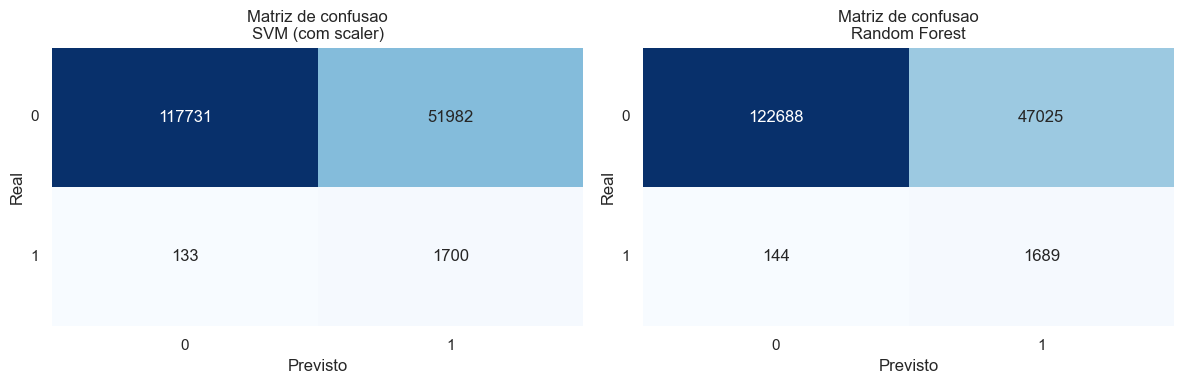

In [23]:
display(svm_tuning_df.head(10))
display(rf_tuning_df.head(10))

resultados_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
}).highlight_max(subset=['Recall'], color='#d9ead3')

fig, axes = plt.subplots(1, len(matrizes), figsize=(12, 4))
if len(matrizes) == 1:
    axes = [axes]

for ax, (nome, matriz) in zip(axes, matrizes.items()):
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Matriz de confusao\n{nome}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_xticklabels(['0', '1'])
    ax.set_yticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

#### Conclusão da Parte 5

- O `SVM` foi treinado dentro de `Pipeline` com `StandardScaler`, etapa essencial para modelos baseados em distância/margem.
- O `Random Forest` foi treinado como alternativa robusta baseada em árvores, menos sensível a escala.
- Foi realizado **tuning leve** com `GridSearchCV` para os dois modelos, usando grade pequena e `recall` como métrica principal.
- A comparação final no conjunto de teste permite escolher o modelo mais aderente ao objetivo do projeto.
- Em cenário de saúde, a prioridade continua sendo reduzir falsos negativos; por isso, `recall` é o critério central da decisão.